In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [44]:
column_headers = ['idx', 'class', 'src_pcd', 'trg_pcd', 'success', 'num corr', 'rrmse', 'trmse', 'crd', 'cd', 'c_loss', 'FMR', 'occ_loss', 'occ_FMR', 'p_loss', 'o_loss']

df = pd.read_csv('../unet_v1_local_k32.txt', sep = "|",  header=None, names=column_headers)

df['min_pcd'] = df[['src_pcd', 'trg_pcd']].min(axis=1)
df['max_pcd'] = df[['src_pcd', 'trg_pcd']].max(axis=1)
df['ratio'] = df['min_pcd']/df['max_pcd']*100

In [45]:
df

,idx,class,src_pcd,trg_pcd,success,num corr,rrmse,trmse,crd,cd,c_loss,FMR,occ_loss,occ_FMR,p_loss,o_loss,min_pcd,max_pcd,ratio
0,0,BeerBottle,3944,1055,29,745,1.22,0.58,0.17,0.02,1.990,0.641,1.941,0.742,0.410,0.323,1055,3944,26.749493
1,1,Bottle,4737,262,31,1015,0.22,0.19,0.01,0.00,1.341,0.945,1.402,0.977,0.403,0.293,262,4737,5.530927
2,2,Bottle,4620,379,32,796,0.84,0.59,0.02,0.00,1.397,0.867,1.482,0.961,0.271,0.393,379,4620,8.203463
3,3,Bottle,4713,286,32,762,2.19,0.61,0.02,0.00,1.469,0.922,1.519,0.938,0.269,0.318,286,4713,6.068322
4,4,Bottle,4654,345,32,794,0.83,0.48,0.02,0.00,1.248,0.977,1.331,0.961,0.278,0.321,345,4654,7.412978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,184,WineBottle,4644,355,32,1670,0.91,0.44,0.02,0.00,1.259,0.984,1.284,0.969,0.680,0.272,355,4644,7.644272
185,185,WineBottle,4176,823,32,904,5.35,1.56,0.22,0.03,1.727,0.820,1.698,0.914,0.450,0.322,823,4176,19.707854
186,186,WineBottle,4652,347,32,1542,1.04,0.64,0.02,0.00,1.274,0.992,1.345,0.977,0.632,0.320,347,4652,7.459157
187,187,WineGlass,4877,256,26,301,1.50,0.64,0.03,0.00,1.457,0.938,1.460,0.906,0.138,0.224,256,4877,5.249129


In [48]:
df[df['rrmse']>50]

,idx,class,src_pcd,trg_pcd,success,num corr,rrmse,trmse,crd,cd,c_loss,FMR,occ_loss,occ_FMR,p_loss,o_loss,min_pcd,max_pcd,ratio
24,24,Bottle,4766,256,0,168,69.65,23.04,0.58,0.04,2.351,0.211,2.449,0.242,0.206,0.576,256,4766,5.371381
40,40,Cookie,4823,256,10,694,117.13,19.20,0.49,0.02,2.195,0.148,2.152,0.203,0.716,1.671,256,4823,5.307900
41,41,Cookie,4742,257,7,406,111.51,5.62,0.58,0.03,2.433,0.125,2.526,0.086,0.437,2.359,257,4742,5.419654
57,57,DrinkingUtensil,4925,256,0,55,128.96,39.44,0.53,0.02,2.330,0.026,2.453,0.000,0.062,2.760,256,4925,5.197970
61,61,Mirror,4871,256,8,303,115.52,18.87,0.45,0.00,2.320,0.320,2.250,0.227,0.231,2.255,256,4871,5.255594
64,64,Mirror,4832,256,1,223,102.88,1.36,0.49,0.01,2.812,0.086,2.847,0.086,0.199,2.261,256,4832,5.298013
68,68,Mirror,4906,256,2,402,98.78,31.13,0.29,0.01,2.145,0.133,2.123,0.125,0.382,2.732,256,4906,5.218100
72,72,Mirror,4897,256,2,368,105.66,3.03,0.33,0.00,2.686,0.102,2.519,0.141,0.281,1.989,256,4897,5.227690
73,73,Mirror,4848,256,0,418,106.17,23.29,0.39,0.01,2.760,0.164,2.953,0.133,0.453,2.173,256,4848,5.280528
74,74,Mirror,3785,256,0,261,127.60,43.95,0.45,0.01,2.173,0.195,2.204,0.234,0.483,1.144,256,3785,6.763540


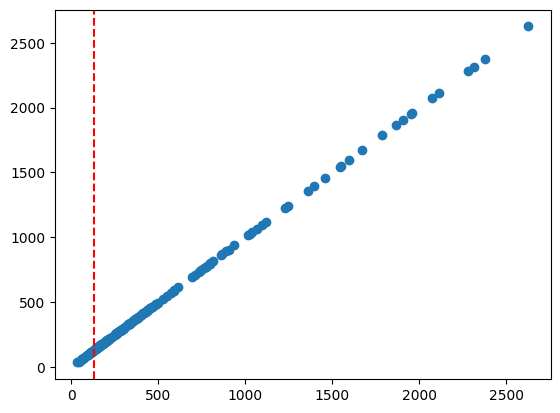

In [42]:
plt.scatter(df['num_corr'], df['num_corr'])
plt.axvline(x=128, color='red', linestyle='--', label='x=128')

plt.show()


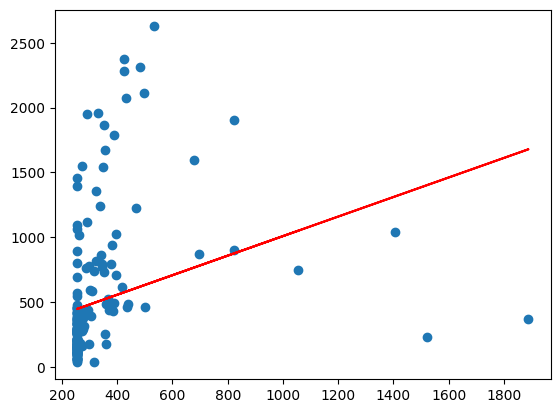

In [16]:
from sklearn.linear_model import LinearRegression

X = df['min_pcd'].values.reshape(-1, 1)  # 독립 변수
y = df['num_corr'].values  # 종속 변수
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
plt.scatter(df['min_pcd'], df['num_corr'])
plt.plot(df['min_pcd'], y_pred, color='red', label='Regression Line')
plt.show()


295.0

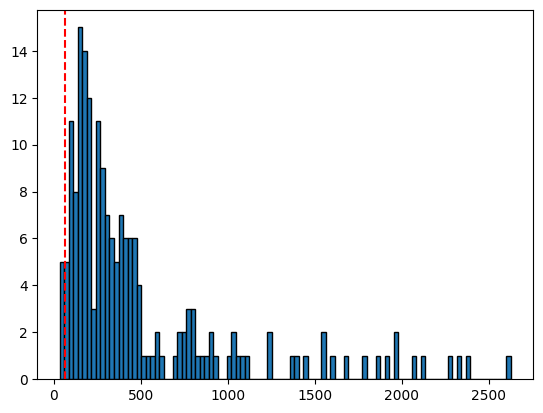

In [46]:
plt.hist(df['num_corr'], bins=100, edgecolor='black')
plt.axvline(x=64, color='red', linestyle='--', label='x=128')

df['num_corr'].median()

In [6]:
df_diff = v7.copy()
for col in v7.columns[4:]:  # Skip 'idx' column
    df_diff[col] = v7[col] - unet_v1[col]

In [36]:
class_metrics = df_diff.groupby('class').mean(numeric_only=True)

In [38]:
class_metrics

,idx,src_pcd,trg_pcd,rrmse,trmse,crd,cd,c_loss,occ_loss,p_loss,o_loss
class,,,,,,,,,,,
BeerBottle,0.0,3944.000000,1055.000000,-2.670000,-0.300000,-1.700000e-01,-2.000000e-02,-0.032000,-0.069000,-0.026000,0.106000
Bottle,13.5,4718.307692,310.615385,-0.900385,0.246538,-1.153846e-03,7.692308e-04,0.360923,0.310769,0.096731,0.333769
Bowl,33.0,4376.615385,735.769231,0.347692,0.564615,1.000000e-02,1.334403e-19,0.372538,0.335077,0.068846,0.407923
Cookie,41.0,4778.666667,256.333333,-19.763333,-9.713333,-6.000000e-02,-2.333333e-02,-0.056333,-0.033000,-0.035333,-0.119000
Cup,47.0,4227.888889,814.666667,0.771111,0.208889,6.666667e-03,3.333333e-03,0.298333,0.264111,0.351000,0.439000
DrinkBottle,53.0,4704.666667,294.666667,1.756667,-0.016667,5.782412e-19,-3.333333e-03,0.412000,0.350667,0.208333,0.814667
DrinkingUtensil,56.5,4812.750000,316.750000,-26.710000,-12.047500,-7.750000e-02,-2.500000e-03,0.198750,0.135500,0.042500,0.011000
Mirror,68.0,4718.157895,272.631579,0.187895,-1.151579,8.684211e-02,6.842105e-03,-0.054684,-0.057947,0.030579,0.010789
Mug,88.5,4722.909091,351.090909,6.682727,1.956364,9.590909e-02,4.090909e-02,0.277955,0.263955,0.071000,0.423682


In [28]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [49]:
    trainer = pl.Trainer(
        logger=logger,
        accelerator='gpu',
        devices=all_gpus,
        precision=32,
        gradient_clip_val=None,
        strategy=args.parallel_strategy,
        max_epochs=args.epochs,
        callbacks=callbacks,
        check_val_every_n_epoch=1,
        profiler='simple',
        fast_dev_run=False,
        enable_progress_bar=False,
    )


NameError: name 'pl' is not defined

In [ ]:
#!/bin/sh

#SBATCH -J unet_legacy_v1_full # Job name

#SBATCH -o ./outputs/unet_legacy_v1_full.%j.out # log file path
#SBATCH -t 3-00:00:00

#### Select GPU
#SBATCH -p titanrtx # {titanxp/titanrtx/2080ti}
#SBATCH --gres=gpu:4 # number of gpus you want to use

#SBATCH --nodes=1
#SBTACH --ntasks=1
##SBATCH --tasks-per-node=1
#SBATCH --cpus-per-task=16

cd $SLURM_SUBMIT_DIR
echo "SLURM_SUBMIT_DIR=$SLURM_SUBMIT_DIR"
echo "CUDA_HOME=$CUDA_HOME"
echo "CUDA_VISIBLE_DEVICES=$CUDA_VISIBLE_DEVICES"
echo "CUDA_VERSION=$CUDA_VERSION"

LD_LIBRARY_PATH=$CUDA_HOME/lib64/
export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/home/nahyuklee/anaconda3/lib/

echo "LD_LIBRARY_PATH=$LD_LIBRARY_PATH"

srun -l /bin/hostname
srun -l /bin/pwd
srun -l /bin/date

module purge

echo "Start" 

WANDB_MODE=offline python3 main.py --model unet_legacy_v1 --scale full --logpath unet_legacy_v1_full --gpus 0 1 2 3 

date

squeue --job $SLURM_JOBID
echo "##### END #####"
